In [ ]:
#!pip install pyspark

## Introduction

In this assignment I use the Iris dataset. It has 150 flower samples from three species: setosa, versicolor, and virginica. Each sample has four measurements: sepal length, sepal width, petal length, and petal width. The job is to build a model that can predict the correct species just from these four numbers.

I test three classification algorithms from Spark MLlib:

- Decision Tree : It works by asking simple yes/no questions about the features (for example, “is petal length ≤ 2.5?”) and splits the data step by step. The final result looks like a flowchart, so it’s very easy to understand.
- Multilayer Perceptron (MLP) : This is a small neural network with a few connected layers. It can learn more complicated patterns than a tree or a straight line, but the inside is like a black box – it’s hard to explain exactly why it gives a certain answer.
- Logistic Regression : It uses a linear formula to draw boundaries between classes. The model is simple, fast, and you can look at the numbers to see which features matter most. The downside is it can only draw straight boundaries, so it may not work well if the data is not linear.

i use google colab run this notebook. I load the data, do some basic preparation, split it into training and testing sets, and then tune each model with cross‑validation and grid search. In the end I compare their accuracy, F1‑score, precision, and confusion matrices to pick the best model for this dataset.


In [2]:

from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

print("Spark starte")


Spark starte


In [5]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data

--2026-07-29 12:53:13--  https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘iris.data’

iris.data               [ <=>                ]   4.44K  --.-KB/s    in 0s      

2026-07-29 12:53:13 (76.7 MB/s) - ‘iris.data’ saved [4551]



# 1. load data

In [6]:

import pandas as pd

df_pd = pd.read_csv("iris.data",
    names=['sepal_len', 'sepal_wid', 'petal_len', 'petal_wid', 'species']
)

df =spark.createDataFrame(df_pd)
df.show(10)
print("total count:", df.count())


+---------+---------+---------+---------+-----------+
|sepal_len|sepal_wid|petal_len|petal_wid|    species|
+---------+---------+---------+---------+-----------+
|      5.1|      3.5|      1.4|      0.2|Iris-setosa|
|      4.9|      3.0|      1.4|      0.2|Iris-setosa|
|      4.7|      3.2|      1.3|      0.2|Iris-setosa|
|      4.6|      3.1|      1.5|      0.2|Iris-setosa|
|      5.0|      3.6|      1.4|      0.2|Iris-setosa|
|      5.4|      3.9|      1.7|      0.4|Iris-setosa|
|      4.6|      3.4|      1.4|      0.3|Iris-setosa|
|      5.0|      3.4|      1.5|      0.2|Iris-setosa|
|      4.4|      2.9|      1.4|      0.2|Iris-setosa|
|      4.9|      3.1|      1.5|      0.1|Iris-setosa|
+---------+---------+---------+---------+-----------+
only showing top 10 rows
total count: 150


# 2. prepare data

In [7]:

from pyspark.ml.feature import StringIndexer, VectorAssembler
# transfer to numeric data
indexer = StringIndexer(inputCol="species", outputCol="label")

featue_cols = ['sepal_len', 'sepal_wid', 'petal_len', 'petal_wid']
assembler = VectorAssembler(inputCols=featue_cols, outputCol="features")

df_prep = indexer.fit(df).transform(df)
df_prep = assembler.transform(df_prep)

df_prep.select("features", "label", "species").show(5)


+-----------------+-----+-----------+
|         features|label|    species|
+-----------------+-----+-----------+
|[5.1,3.5,1.4,0.2]|  0.0|Iris-setosa|
|[4.9,3.0,1.4,0.2]|  0.0|Iris-setosa|
|[4.7,3.2,1.3,0.2]|  0.0|Iris-setosa|
|[4.6,3.1,1.5,0.2]|  0.0|Iris-setosa|
|[5.0,3.6,1.4,0.2]|  0.0|Iris-setosa|
+-----------------+-----+-----------+
only showing top 5 rows


# 3. train and test dataset split

In [8]:

train, test = df_prep.randomSplit([0.8, 0.2],seed=12333)
print("train:  " , train.count(),"test: ", test.count())
print("train datset composition ")
train.groupBy("species").count().show()

train:   128 test:  22
train datset composition 
+---------------+-----+
|        species|count|
+---------------+-----+
|    Iris-setosa|   43|
|Iris-versicolor|   43|
| Iris-virginica|   42|
+---------------+-----+



# 4. evaluate on test dataset

In [9]:


from pyspark.ml.evaluation import MulticlassClassificationEvaluator

def my_evaluate(preds):
    #acc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction",metricName="accuracy")
    acc_eval=MulticlassClassificationEvaluator(metricName="accuracy")
    acc=acc_eval.evaluate(preds)

    f1_eval=MulticlassClassificationEvaluator(metricName="f1")
    f1=f1_eval.evaluate(preds)

    prec_eval=MulticlassClassificationEvaluator(metricName="weightedPrecision")
    prec = prec_eval.evaluate(preds)

    print("\n result:" )
    print("  accuracy:   " , round(acc,3))
    print("  f1 score:   " , round(f1,3))
    print("  precision:   " , round(prec,3))

    return {'acc': acc, 'f1': f1, 'prec': prec}



# 5. model 1 --- decision tree

In [10]:


from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=1111)

#param grid
dt_grid = ParamGridBuilder().addGrid(dt.maxDepth, [3, 5, 7]).build()

#cross validation
dt_cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=dt_grid,
    evaluator=MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    ),
    numFolds=3,
    seed=1111
)

# fit model
dt_model = dt_cv.fit(train)

dt_best = dt_model.bestModel
print("best maxDepth: " , str(dt_best.getMaxDepth()))

print("Decision Tree:")
dt_pred = dt_model.transform(test)
dt_result = my_evaluate(dt_pred)



best maxDepth:  5
Decision Tree:

 result:
  accuracy:    0.909
  f1 score:    0.908
  precision:    0.929


In [11]:
dt_pred.show(10)

+---------+---------+---------+---------+---------------+-----+-----------------+--------------+-------------+----------+
|sepal_len|sepal_wid|petal_len|petal_wid|        species|label|         features| rawPrediction|  probability|prediction|
+---------+---------+---------+---------+---------------+-----+-----------------+--------------+-------------+----------+
|      4.4|      3.2|      1.3|      0.2|    Iris-setosa|  0.0|[4.4,3.2,1.3,0.2]|[43.0,0.0,0.0]|[1.0,0.0,0.0]|       0.0|
|      4.7|      3.2|      1.6|      0.2|    Iris-setosa|  0.0|[4.7,3.2,1.6,0.2]|[43.0,0.0,0.0]|[1.0,0.0,0.0]|       0.0|
|      4.8|      3.0|      1.4|      0.3|    Iris-setosa|  0.0|[4.8,3.0,1.4,0.3]|[43.0,0.0,0.0]|[1.0,0.0,0.0]|       0.0|
|      5.0|      3.5|      1.3|      0.3|    Iris-setosa|  0.0|[5.0,3.5,1.3,0.3]|[43.0,0.0,0.0]|[1.0,0.0,0.0]|       0.0|
|      5.2|      3.5|      1.5|      0.2|    Iris-setosa|  0.0|[5.2,3.5,1.5,0.2]|[43.0,0.0,0.0]|[1.0,0.0,0.0]|       0.0|
|      5.5|      4.2|   

# 6. model 2 --- mlp

In [12]:


from pyspark.ml.classification import MultilayerPerceptronClassifier

# layers: 4 input, hidden 5 and 4, output 3
layers = [4, 2, 3]

mlp = MultilayerPerceptronClassifier(
    maxIter=50,
    layers=layers,
    seed=1111,
    featuresCol="features",
    labelCol="label"
)

# fit model
mlp_model = mlp.fit(train)

print("MLP:")
mlp_preds = mlp_model.transform(test)
mlp_result = my_evaluate(mlp_preds)




MLP:

 result:
  accuracy:    1.0
  f1 score:    1.0
  precision:    1.0


# 7. model 3 --- logistic regression

In [13]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",

    maxIter=100
)

# param grid
lr_grid = ParamGridBuilder() \
    .addGrid(lr.regParam,  [0.1, 0.5 ,1.0])\
    .build()

# cross validation
lr_cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=lr_grid,
    evaluator=MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy"
    ),
    numFolds=3,
    seed=1111
)


lr_model = lr_cv.fit(train)
lr_best = lr_model.bestModel

print("Logistic Regression")
lr_preds = lr_model.transform(test)
lr_result = my_evaluate(lr_preds)

Logistic Regression

 result:
  accuracy:    0.909
  f1 score:    0.907
  precision:    0.927


##

In [14]:
print("\nmodel     acc        f1        precision")
print("DT        "+str(round(dt_result['acc'], 4))+"     " + str(round(dt_result['f1'], 4)) +"     " + str(round(dt_result['prec'], 4)))
print("MLP       "+str(round(mlp_result['acc'], 4))+ "        " + str(round(mlp_result['f1'], 4))+ "        " + str(round(mlp_result['prec'], 4)))
print("Logistic  "+str(round(lr_result['acc'], 4))+"     " + str(round(lr_result['f1'], 4)) +"     " + str(round(lr_result['prec'], 4)))


model     acc        f1        precision
DT        0.9091     0.9083     0.9293
MLP       1.0        1.0        1.0
Logistic  0.9091     0.9066     0.9273


prediction  0.0  1.0  2.0
label                    
0.0           7    0    0
1.0           0    7    0
2.0           0    2    6
prediction  0.0  1.0  2.0
label                    
0.0           7    0    0
1.0           0    7    0
2.0           0    0    8
prediction  0.0  1.0  2.0
label                    
0.0           7    0    0
1.0           0    5    2
2.0           0    0    8


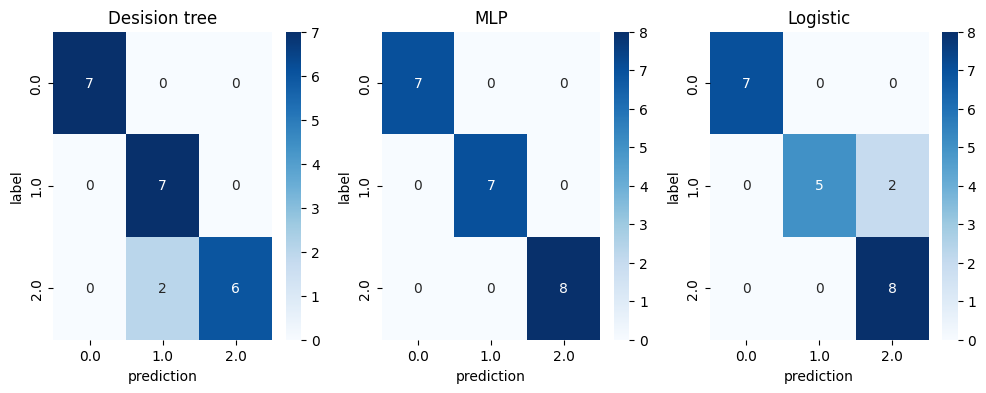

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#trans to panda
dt_pd = dt_pred.select("label", "prediction").toPandas()
mlp_pd = mlp_preds.select("label", "prediction").toPandas()
lr_pd = lr_preds.select("label", "prediction").toPandas()


Confu_matrix_dt=pd.crosstab(dt_pd['label'],dt_pd['prediction'])
Confu_matrix_mlp=pd.crosstab(mlp_pd['label'],mlp_pd['prediction'])
Confu_matrix_lr=pd.crosstab(lr_pd['label'],lr_pd['prediction'])


print(Confu_matrix_dt)
print(Confu_matrix_mlp)
print(Confu_matrix_lr)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.heatmap(Confu_matrix_dt,annot=True,cmap='Blues',ax=axes[0])
axes[0].set_title('Desision tree')
sns.heatmap(Confu_matrix_mlp,annot=True,fmt='d',cmap='Blues', ax=axes[1])
axes[1].set_title('MLP')
sns.heatmap(Confu_matrix_lr,annot=True,cmap='Blues',ax=axes[2])
axes[2].set_title('Logistic')


plt.show()


# 8. Compare

From the results, MLP got 1.0 on all three measures, so it's the best here. Decision Tree and Logistic Regression both got about 0.91, so they were very close. But if we look at where they got things wrong, the mistakes are different.

### Looking at the confusion matrices:

DT got all class 0 and class 1 right, but class 2 had 2 wrong — they were put into class 1.

MLP got everything right.

LR got all class 0 and class 2 right, but class 1 had 2 wrong — they were put into class 2.

So DT and LR both made 2 mistakes, but in opposite ways. DT messes up class 2 as class 1.
LR messes up class 1 as class 2. They both struggle between those two classes, just in different directions. MLP didn't mess up at all on this small test set.

### Good and bad :

Decision Tree

Good: easy to understand, you can see the rules, handles non‑linear patterns.

Bad: can overfit if tree grows too deep, still mixes up class 1 and class 2 a bit.

Multilayer Perceptron

Good: very strong fitting power, got perfect scores this run.

Bad: hard to explain what it does inside, training takes longer, the perfect score could just be luck because the test set is so small. We didn't tune it with cross‑validation so maybe it won't stay perfect next time.

Logistic Regression

Good: super simple, fast, easy to read the weights.

Bad: only linear boundaries, not so good for non‑linear data, also mixes up class 1 and class 2.

### So what's the choice?

If i want a model that i can explain easily and trust, i will go with Decision Tree. It's simple and stable. If i just want the highest accuracy number on this test set today, i will pick MLP, but it might not do so well on new data(especially without tuning). Logistic Regression is a quick baseline that still gives decent results.

The limitation here is that the test set only has 22 samples. All these numbers might change if we try a different split. So the 1.0 from MLP not necessarily reliable. DT and LR are safer choice for new data.

# 9. Test on best model
This is the best model I chose -- MLP. Here is how it does on the test set:
- Total test samples:  22
- Correct : 22
- Wrong: 0

In [16]:


preds = mlp_model.transform(test)
preds.show(10)

correct = preds.filter("label = prediction").count()
wrong = preds.filter("label != prediction").count()
print("\n correct: %d, wrong: %d" % (correct, wrong))





+---------+---------+---------+---------+---------------+-----+-----------------+--------------------+--------------------+----------+
|sepal_len|sepal_wid|petal_len|petal_wid|        species|label|         features|       rawPrediction|         probability|prediction|
+---------+---------+---------+---------+---------------+-----+-----------------+--------------------+--------------------+----------+
|      4.4|      3.2|      1.3|      0.2|    Iris-setosa|  0.0|[4.4,3.2,1.3,0.2]|[29.7783545451229...|[0.99999999999899...|       0.0|
|      4.7|      3.2|      1.6|      0.2|    Iris-setosa|  0.0|[4.7,3.2,1.6,0.2]|[29.3530512606298...|[0.99999999999835...|       0.0|
|      4.8|      3.0|      1.4|      0.3|    Iris-setosa|  0.0|[4.8,3.0,1.4,0.3]|[29.1028383747530...|[0.99999999999780...|       0.0|
|      5.0|      3.5|      1.3|      0.3|    Iris-setosa|  0.0|[5.0,3.5,1.3,0.3]|[31.0588939084957...|[0.99999999999977...|       0.0|
|      5.2|      3.5|      1.5|      0.2|    Iris-setos

In [ ]:

spark.stop()